<a href="https://colab.research.google.com/github/lahiru-praveen/quantization-aware-machine-unlearning-slm/blob/develop/notebooks/06_bucket_collapse_eval_using_phi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bucket Collapse Replication: Microsoft Phi-3

This notebook replicates the quantization-induced unlearning failure (bucket collapse)
> *Catastrophic Failure of LLM Unlearning via Quantization (Zhang et al., ICLR 2025)*

**Model:** `microsoft/Phi-3-mini-4k-instruct` (3.8B params) — a much lighter alternative to LLaMA-2 7B, making it accessible on a single GPU with less VRAM.

**Core claim being replicated:** Standard machine unlearning (GA-GDR) produces weight updates so small that 4-bit quantization maps the unlearned model's weights back into the same quantization buckets as the original model — effectively *undoing* the unlearning.

---
### Pipeline Overview
1. **Install** dependencies
2. **Fine-tune** Phi-3 on MUSE-News (target model)
3. **Unlearn** the forget set via GA-GDR (unlearned model)
4. **Merge** LoRA adapters into full FP16 weights
5. **Analyse** weight-change statistics and bucket overlap at 16/8/4-bit
6. **Visualise** layer-wise overlap + per-tensor histograms
7. **Functional proof** — text generation before/after quantization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 1 — Install Dependencies

In [ ]:
#  run this when cannot upgrade transformers
# Patches the cached modeling_phi3.py to accept both 'type' and 'rope_type'

import pathlib

cache_root = pathlib.Path.home() / '.cache/huggingface/modules/transformers_modules'
candidates = list(cache_root.glob('microsoft/*/modeling_phi3.py'))

if not candidates:
    print('No cached modeling_phi3.py found.')
    print('Run Cell 3 once (it will fail but download the file), then re-run this cell.')
else:
    for path in candidates:
        text = path.read_text()
        old_line = 'scaling_type = self.config.rope_scaling["type"]'
        new_line = (
            '# Patched: handle both "type" (old) and "rope_type" (new) key names\n'
            '            rs = self.config.rope_scaling\n'
            '            scaling_type = rs.get("rope_type") or rs.get("type")'
        )
        if old_line in text:
            path.write_text(text.replace(old_line, new_line))
            print('Patched:', path)
        elif 'rope_type' in text:
            print('Already up-to-date:', path)
        else:
            print('Pattern not found — inspect manually:', path)

    # Force Python to re-import the patched file
    import sys
    stale = [k for k in sys.modules if 'phi3' in k.lower() or 'phi_3' in k.lower()]
    for m in stale:
        del sys.modules[m]
    print('Module cache cleared — proceed to Cell 3.')


No cached modeling_phi3.py found.
Run Cell 3 once (it will fail but download the file), then re-run this cell.


In [ ]:
# Step 1: Clear the stale cached modeling_phi3.py
import shutil, pathlib
for p in pathlib.Path.home().glob('.cache/huggingface/modules/transformers_modules/microsoft/*'):
    shutil.rmtree(p, ignore_errors=True)
    print(f'Cleared cache: {p}')

# Step 2: Upgrade transformers so Phi-3 arch is built-in (no remote code version skew)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-U',
    'transformers>=4.43.0', 'accelerate', 'datasets', 'peft', 'trl'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-U',
    'bitsandbytes>=0.46.1'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'matplotlib', 'scipy'], check=True)

import importlib
import transformers
importlib.reload(transformers)
print('transformers version:', transformers.__version__)


transformers version: 5.5.4


## Cell 2 — Setup Paths

In [ ]:
import os

# ── Change BASE_DIR to wherever you want to persist models ──
BASE_DIR = '/content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models'

TARGET_ADAPTER_DIR   = os.path.join(BASE_DIR, 'target_model_lora')
UNLEARNED_ADAPTER_DIR = os.path.join(BASE_DIR, 'unlearned_model_lora')
TARGET_FP16_DIR      = os.path.join(BASE_DIR, 'target_model_fp16')
UNLEARNED_FP16_DIR   = os.path.join(BASE_DIR, 'unlearned_model_fp16')

for d in [TARGET_ADAPTER_DIR, UNLEARNED_ADAPTER_DIR, TARGET_FP16_DIR, UNLEARNED_FP16_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready:")
for d in [TARGET_ADAPTER_DIR, UNLEARNED_ADAPTER_DIR, TARGET_FP16_DIR, UNLEARNED_FP16_DIR]:
    print(f"  {d}")

Directories ready:
  /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_lora
  /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/unlearned_model_lora
  /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_fp16
  /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/unlearned_model_fp16


## Cell 3 — Load Phi-3 with LoRA

**Key Phi-3 differences vs LLaMA-2:**
- Model ID: `microsoft/Phi-3-mini-4k-instruct`
- Attention modules are named `qkv_proj` (fused) and `o_proj` — not separate `q_proj`, `k_proj`, `v_proj`
- Requires `trust_remote_code=True` because Phi-3's architecture includes custom modelling code
- `attn_implementation="eager"` is the safe fallback if flash-attn is unavailable

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_ID = 'microsoft/Phi-3-mini-4k-instruct'
REVISION = 'main'

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, revision=REVISION, trust_remote_code=True
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16
)

print('Loading Phi-3 base model in 4-bit...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    attn_implementation='eager',
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
)

target_model = get_peft_model(model, lora_config)
target_model.print_trainable_parameters()
print('Ready for fine-tuning.')


Loading Phi-3 base model in 4-bit...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

trainable params: 25,165,824 || all params: 3,846,245,376 || trainable%: 0.6543
Ready for fine-tuning.


## Cell 4 — Fine-Tune Target Model on MUSE-News

Train on `forget ∪ retain` for 10 epochs with lr = 1e-5.

In [ ]:
from datasets import load_dataset, concatenate_datasets
from trl import SFTTrainer, SFTConfig

print("Downloading MUSE-News dataset...")
dataset = load_dataset("muse-bench/MUSE-News", "raw")

forget_set = dataset["forget"]
retain_set  = dataset["retain1"]
train_data  = concatenate_datasets([forget_set, retain_set]).shuffle(seed=42)

print(f"Forget set size : {len(forget_set)}")
print(f"Retain set size : {len(retain_set)}")
print(f"Total train size: {len(train_data)}")

training_args = SFTConfig(
    output_dir=TARGET_ADAPTER_DIR,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1e-5,
    logging_steps=10,
    num_train_epochs=10,
    save_strategy="epoch",
    bf16=True,
    optim="paged_adamw_32bit",
    max_length=2048,
)

trainer = SFTTrainer(
    model=target_model,
    train_dataset=train_data,
    args=training_args,
    processing_class=tokenizer,
)

print("Starting fine-tuning of Phi-3 target model...")
trainer.train()

trainer.model.save_pretrained(TARGET_ADAPTER_DIR)
tokenizer.save_pretrained(TARGET_ADAPTER_DIR)
print(f"Target model LoRA adapters saved to: {TARGET_ADAPTER_DIR}")

README.md: 0.00B [00:00, ?B/s]

raw/retain2-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

raw/forget-00000-of-00001.parquet:   0%|          | 0.00/1.93M [00:00<?, ?B/s]

raw/retain1-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

raw/holdout-00000-of-00001.parquet:   0%|          | 0.00/5.48M [00:00<?, ?B/s]

...

Token indices sequence length is longer than the specified maximum sequence length for this model (13597 > 4096). Running this sequence through the model will result in indexing errors


Starting fine-tuning of Phi-3 target model...


Step,Training Loss
10,1.991602
20,1.986069
30,1.953580
40,1.950674
50,1.957313
60,1.939323
70,1.923960
80,1.954112
90,1.963205
100,1.956262


Step,Training Loss
10,1.991602
20,1.986069
30,1.953580
40,1.950674
50,1.957313
60,1.939323
70,1.923960
80,1.954112
90,1.963205
100,1.956262


Target model LoRA adapters saved to: /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_lora


## Cell 5 — Unlearn the Forget Set via GA-GDR

Gradient Ascent on the forget set (maximises loss → pushes away from forget-set labels) combined with Gradient Descent on the retain set (minimises loss → preserves utility).

The **small learning rate (1e-5)** and **utility constraint (α = 5)** are exactly what cause weight updates to be tiny - cause to the bucket collapse.

In [ ]:
import torch
import gc
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig, DataCollatorForLanguageModeling
)
from peft import PeftModel, prepare_model_for_kbit_training

# ── 1. Clear VRAM ─────────────────────────────────────────────────────────────
print("Clearing GPU memory...")
for var in ['target_model', 'trainer', 'model']:
    if var in dir():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

# ── 2. Reload base Phi-3 + attach target adapters ─────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading Phi-3 base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="eager",
)
base_model = prepare_model_for_kbit_training(base_model)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Attaching target model adapters from: {TARGET_ADAPTER_DIR}")
unlearning_model = PeftModel.from_pretrained(
    base_model, TARGET_ADAPTER_DIR, is_trainable=True
)

# ── 3. Tokenise datasets ──────────────────────────────────────────────────────
print("Tokenising datasets...")

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=2048)

tokenized_forget = forget_set.map(tokenize_fn, batched=True, remove_columns=forget_set.column_names)
tokenized_retain = retain_set.map(tokenize_fn, batched=True, remove_columns=retain_set.column_names)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

forget_loader = DataLoader(tokenized_forget, batch_size=2, shuffle=True, collate_fn=data_collator)
retain_loader = DataLoader(tokenized_retain, batch_size=2, shuffle=True, collate_fn=data_collator)

# ── 4. GA-GDR Unlearning Loop ─────────────────────────────────────────────────
LEARNING_RATE = 1e-5   # Deliberately small — this is the key parameter that causes collapse
ALPHA         = 5.0    # Utility constraint weight (from paper)
EPOCHS        = 10

optimizer = torch.optim.AdamW(unlearning_model.parameters(), lr=LEARNING_RATE)
unlearning_model.train()

print("Starting GA-GDR unlearning on Phi-3...")
for epoch in range(EPOCHS):
    for forget_batch, retain_batch in zip(forget_loader, retain_loader):

        forget_batch = {k: v.to(unlearning_model.device) for k, v in forget_batch.items()}
        retain_batch = {k: v.to(unlearning_model.device) for k, v in retain_batch.items()}

        optimizer.zero_grad()

        # Gradient Ascent: negate the cross-entropy on forget examples
        forget_loss = -unlearning_model(**forget_batch).loss

        # Gradient Descent: standard cross-entropy on retain examples
        retain_loss = unlearning_model(**retain_batch).loss

        # Combined objective: L_forget + α · L_retain
        total_loss = forget_loss + (ALPHA * retain_loss)
        total_loss.backward()
        optimizer.step()

    print(f"  Epoch {epoch+1}/{EPOCHS} done.")

# ── 5. Save unlearned adapters ────────────────────────────────────────────────
unlearning_model.save_pretrained(UNLEARNED_ADAPTER_DIR)
print(f"Unlearned adapters saved to: {UNLEARNED_ADAPTER_DIR}")

Clearing GPU memory...
Loading Phi-3 base model...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Attaching target model adapters from: /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_lora
Tokenising datasets...


Map:   0%|          | 0/889 [00:00<?, ? examples/s]

Map:   0%|          | 0/1777 [00:00<?, ? examples/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Starting GA-GDR unlearning on Phi-3...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  Epoch 1/10 done.
  Epoch 2/10 done.
  Epoch 3/10 done.
  Epoch 4/10 done.
  Epoch 5/10 done.
  Epoch 6/10 done.
  Epoch 7/10 done.
  Epoch 8/10 done.
  Epoch 9/10 done.
  Epoch 10/10 done.
Unlearned adapters saved to: /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/unlearned_model_lora


## Cell 6 — Merge LoRA Adapters into Full FP16 Models

The bucket-collapse analysis requires comparing raw weight tensors, so we need fully merged FP16 checkpoints (not quantised adapter files).

In [ ]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

def merge_and_save_phi3(base_model_id, adapter_path, save_path):
    """
    Load Phi-3 in FP16, attach LoRA adapters, merge, and save.
    Using native transformers support (no remote code needed).
    """
    print(f"Loading FP16 Phi-3 for: {adapter_path} ...")

    # Let transformers handle the architecture natively
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16,
        device_map="cpu",
        attn_implementation="eager",
    )

    # Tokenizer also loads natively
    tok = AutoTokenizer.from_pretrained(base_model_id)

    peft_model  = PeftModel.from_pretrained(base_model, adapter_path)
    merged      = peft_model.merge_and_unload()

    print(f"Saving merged model to: {save_path}")
    merged.save_pretrained(save_path, safe_serialization=True, max_shard_size="2GB")
    tok.save_pretrained(save_path)

    del base_model, peft_model, merged
    gc.collect()
    torch.cuda.empty_cache()
    print("Done.\n")

# Call your functions as normal:
merge_and_save_phi3(MODEL_ID, TARGET_ADAPTER_DIR,   TARGET_FP16_DIR)
merge_and_save_phi3(MODEL_ID, UNLEARNED_ADAPTER_DIR, UNLEARNED_FP16_DIR)

Loading FP16 Phi-3 for: /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_lora ...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Saving merged model to: /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_fp16


Writing model shards:   0%|          | 0/4 [00:00<?, ?it/s]

Done.

Loading FP16 Phi-3 for: /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/unlearned_model_lora ...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Saving merged model to: /content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/unlearned_model_fp16


Writing model shards:   0%|          | 0/4 [00:00<?, ?it/s]

Done.



## Cell 7 — Load Merged FP16 Models for Analysis

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Loading target (reference) model in bfloat16...")
model_target = AutoModelForCausalLM.from_pretrained(
    TARGET_FP16_DIR,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    # trust_remote_code=True,
    attn_implementation="eager",
)

print("Loading unlearned model in bfloat16...")
model_unlearned = AutoModelForCausalLM.from_pretrained(
    UNLEARNED_FP16_DIR,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    # trust_remote_code=True,
    attn_implementation="eager",
)

print("Both models loaded.")

Loading target (reference) model in bfloat16...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Loading unlearned model in bfloat16...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Both models loaded.


## Cell 8 — Analysis Functions

These mirror Section V of the QUAIL paper exactly.

In [ ]:
import torch
import numpy as np
import bitsandbytes as bnb


def calculate_weight_change_statistics(model_ref, model_unlearned):
    """
    Compute δᵢ = |θ'ᵢ − θᵢ| across all trainable parameters.
    Reports mean, max, and fraction of exact zero-change weights.
    """
    all_deviations = []

    for (name_r, param_r), (_, param_u) in zip(
        model_ref.named_parameters(), model_unlearned.named_parameters()
    ):
        if not param_r.requires_grad:
            continue
        with torch.no_grad():
            dev = torch.abs(param_u.float() - param_r.float())
            all_deviations.append(dev.flatten().cpu())

    all_deviations = torch.cat(all_deviations)

    mean_change    = all_deviations.mean().item()
    max_change     = all_deviations.max().item()
    exact_matches  = (all_deviations == 0).float().mean().item()

    print("─" * 50)
    print("Weight Change Statistics (Phi-3 GA-GDR vs Target)")
    print("─" * 50)
    print(f"  Mean |δᵢ|            : {mean_change:.4e}")
    print(f"  Max  |δᵢ|            : {max_change:.4e}")
    print(f"  Exact bitwise matches: {exact_matches * 100:.2f}%")
    print("─" * 50)
    return mean_change, max_change


def calculate_bucket_overlap(model_ref, model_unlearned, bit_width=4):
    """
    For each weight tensor, compute the quantisation step Δ using the
    reference model's range, assign bucket indices to both models, then
    count how many weights land in the same bucket.

    Skips embedding layers and layer-norm parameters (same as the paper).

    For Phi-3 the parameter names differ from LLaMA-2:
      LLaMA-2: model.layers.N.self_attn.q_proj.weight
      Phi-3  : model.layers.N.self_attn.qkv_proj.weight
               model.layers.N.mlp.gate_up_proj.weight
               model.layers.N.mlp.down_proj.weight
    The layer-index extraction below handles both conventions.
    """
    skip_keywords = ('norm', 'embed', 'lm_head', 'rotary')

    total_params     = 0
    total_overlapped = 0
    layerwise_overlap = {}

    for (name, param_r), (_, param_u) in zip(
        model_ref.named_parameters(), model_unlearned.named_parameters()
    ):
        if any(kw in name for kw in skip_keywords):
            continue

        with torch.no_grad():
            w_r = param_r.float().cpu()
            if hasattr(param_u, "quant_state") and param_u.quant_state is not None:
                # Dequantize back to the original 2D tensor shape using bnb
                w_u_unpacked = bnb.functional.dequantize_4bit(param_u.data, param_u.quant_state)
                w_u = w_u_unpacked.float().cpu()
            else:
                # Normal FP16/BF16/FP32 parameter
                w_u = param_u.float().cpu()

            w_max = w_r.max().item()
            w_min = w_r.min().item()

            delta = (w_max - w_min) / (2 ** bit_width)
            if delta == 0:
                continue

            idx_r = torch.floor((w_r - w_min) / delta)
            idx_u = torch.floor((w_u - w_min) / delta)

            overlap      = (idx_r == idx_u).float().mean().item()
            n_params     = param_r.numel()

            total_overlapped += int(overlap * n_params)
            total_params     += n_params
            layerwise_overlap[name] = overlap

    global_overlap = total_overlapped / total_params if total_params > 0 else 0.0
    return global_overlap, layerwise_overlap


print("Analysis functions defined.")

Analysis functions defined.


## Cell 9 — Run the Replication Tests

This reproduces **Table I** from the QUAIL paper for Phi-3.

In [ ]:
# ── Weight-change statistics ──────────────────────────────────────────────────
mean_shift, max_shift = calculate_weight_change_statistics(model_target, model_unlearned)

# ── Bucket overlap across three precision levels ──────────────────────────────
bit_widths   = [16, 8, 4]
results      = {}
layer_data   = {}

print("\n─" * 5)
print("Quantised Bucket Overlap — Phi-3 (GA-GDR Unlearned vs Target)")
print("─" * 5)
print(f"{'Bit Width':<12} {'Global Overlap':>16}")
print("─" * 3)

for bw in bit_widths:
    overlap, l_overlap = calculate_bucket_overlap(model_target, model_unlearned, bit_width=bw)
    results[bw]    = overlap
    layer_data[bw] = l_overlap
    flag = " ← CATASTROPHIC" if bw == 4 and overlap > 0.999 else ""
    print(f"{bw}-bit       {overlap * 100:>14.4f}%{flag}")

print("─" * 50)

if results[4] > 0.999:
    print("\n⚠️  BUCKET COLLAPSE CONFIRMED for Phi-3!")
    print("   4-bit overlap > 99.9% → the unlearning effect is erased by quantisation.")
elif results[4] > 0.99:
    print("\n⚠️  High 4-bit overlap detected (>99%). Near-total collapse.")
else:
    print("\nℹ️  4-bit overlap is lower than expected. Check hyperparameters.")

──────────────────────────────────────────────────
Weight Change Statistics (Phi-3 GA-GDR vs Target)
──────────────────────────────────────────────────
  Mean |δᵢ|            : 1.5288e-04
  Max  |δᵢ|            : 1.0788e-02
  Exact bitwise matches: 41.56%
──────────────────────────────────────────────────

─
─
─
─
─
Quantised Bucket Overlap — Phi-3 (GA-GDR Unlearned vs Target)
─────
Bit Width      Global Overlap
───
16-bit              39.3564%
8-bit              97.5514%
4-bit              99.8496%
──────────────────────────────────────────────────

⚠️  High 4-bit overlap detected (>99%). Near-total collapse.


## Cell 10 — Figure 1: Layer-wise Bucket Overlap

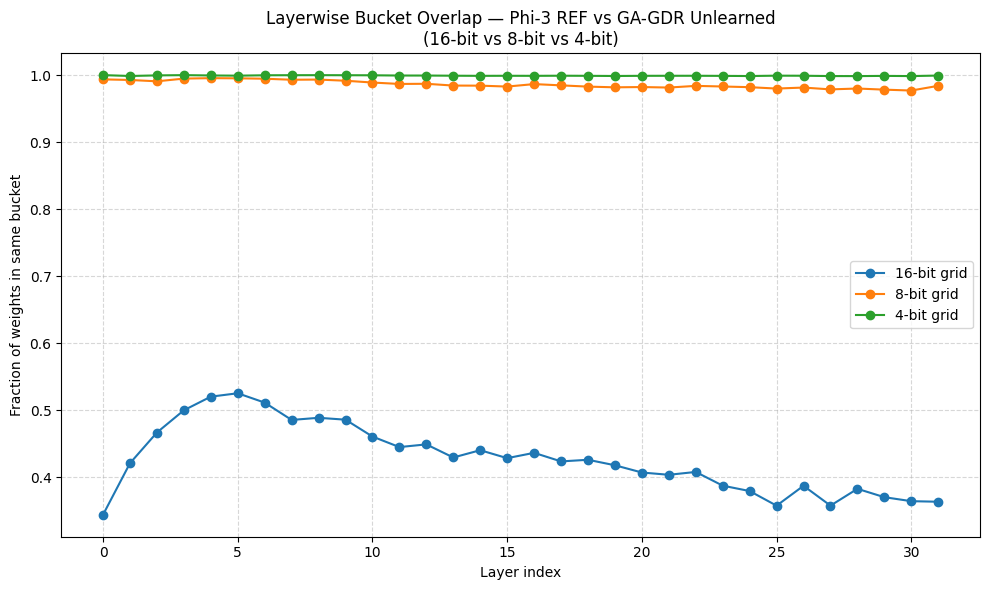

Saved: phi3_layerwise_overlap.png


In [ ]:
import matplotlib.pyplot as plt

# Phi-3 uses 'qkv_proj' (fused QKV) instead of separate 'q_proj'.
# We probe it as the representative attention weight per layer.
PROBE_KEYWORD = "qkv_proj"

plt.figure(figsize=(10, 6))

for bw in bit_widths:
    layers   = []
    overlaps = []

    for name, overlap in layer_data[bw].items():
        if PROBE_KEYWORD in name and 'weight' in name:
            # Name format: model.layers.<idx>.self_attn.qkv_proj.weight
            parts = name.split('.')
            try:
                layer_idx = int(parts[2])
                layers.append(layer_idx)
                overlaps.append(overlap)
            except (IndexError, ValueError):
                pass

    if layers:
        pairs = sorted(zip(layers, overlaps))
        l_sorted, o_sorted = zip(*pairs)
        plt.plot(l_sorted, o_sorted, marker='o', label=f'{bw}-bit grid')

plt.title('Layerwise Bucket Overlap — Phi-3 REF vs GA-GDR Unlearned\n(16-bit vs 8-bit vs 4-bit)')
plt.xlabel('Layer index')
plt.ylabel('Fraction of weights in same bucket')
# plt.ylim(0.30, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('phi3_layerwise_overlap.png', dpi=150)
plt.show()
print("Saved: phi3_layerwise_overlap.png")

**Green Line — 4-bit Grid** (≈ 1.000 flat)

- Overlap: ~99.9–100% across ALL 32 layers  
- Variation: essentially zero  

A perfectly flat line hugging the top. At 4-bit, the bucket width Δ is so large (~0.05–0.27) that every single layer has near-total collapse. There is no layer in Phi-3 that managed to escape — the unlearning signal is erased uniformly and completely everywhere.
  
**4-bit quantisation does not care which layer you look at. Everything collapses.**

---

**Orange Line — 8-bit Grid** (≈ 0.98–0.99)

- Overlap: ~98–99% across all layers  
- Trend: Slight downward trend toward later layers  

Still very high but no longer perfectly flat. There is a subtle pattern:

- Early layers (0–20):  
  Overlap stays tightly around ~99% — almost as bad as 4-bit  

- Later layers (20–31):  
  Overlap dips slightly to ~97–98% — later layers have marginally larger weight changes that 8-bit can just barely detect  

This tells that 8-bit is only slightly better than 4-bit for Phi-3 — unlearning is still mostly erased, though the later layers retain a faint residual signal.

---

**Blue Line — 16-bit Grid**

- Overlap: ~35–53%, varies significantly across layers  
- Pattern: Clear rise-then-fall  

This is the only line with meaningful variation. Breaking it into three regions:

- Early layers (0–5):
  - Rising from **35% → 52%**
  - Layer 0 starts at ~35% overlap — this layer had the largest weight changes relative to bucket size  
  - Overlap rises through layers 1–5, meaning those layers had progressively smaller unlearning updates  

- Mid layers (5–20)
  - Gradual decline from **52% → 42%**
  - Layer 5 is the peak (~52–53%) — the layer where GA-GDR made the least relative change  
  - From layer 6 onwards, overlap slowly decreases, meaning mid-to-late layers start receiving slightly larger gradient updates from the unlearning process  

- Late layers (20–31)
  - Continued decline to **~36%**
  - The last 10 layers show the lowest overlap (~36–40%)  
  - This means GA-GDR's gradient ascent pushed harder on the later layers — they received the most unlearning signal  

**At 16-bit these changes are visible; at 4-bit they are completely swallowed.**

## Cell 11 — Figure 2: Intra-model Collapse

Replicates **Figure 2**: comparing the full-precision unlearned model against its *own* 4-bit quantised version.  
This shows that even the unlearning signal within the same model is destroyed by quantisation.

Loading 4-bit quantised version of the unlearned model...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

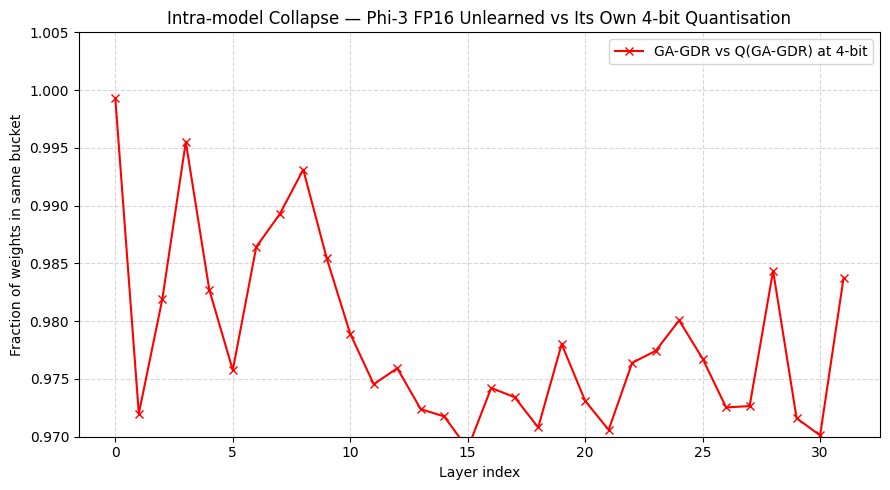

Saved: phi3_intramodel_collapse.png


In [ ]:
import matplotlib.pyplot as plt
from transformers import BitsAndBytesConfig, AutoModelForCausalLM

# Load the unlearned model again in 4-bit
print("Loading 4-bit quantised version of the unlearned model...")
bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=False,   # plain uniform quantisation
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32
)
model_unlearned_4bit = AutoModelForCausalLM.from_pretrained(
    UNLEARNED_FP16_DIR,
    quantization_config=bnb_config_4bit,
    device_map="auto",
    # trust_remote_code=True,
    attn_implementation="eager",
)

# Compare FP16 unlearned vs its 4-bit self
_, intra_layer_data = calculate_bucket_overlap(model_unlearned, model_unlearned_4bit, bit_width=4)

layers_intra   = []
overlaps_intra = []

for name, ov in intra_layer_data.items():
    if PROBE_KEYWORD in name and 'weight' in name:
        parts = name.split('.')
        try:
            layers_intra.append(int(parts[2]))
            overlaps_intra.append(ov)
        except (IndexError, ValueError):
            pass

if layers_intra:
    pairs = sorted(zip(layers_intra, overlaps_intra))
    l_s, o_s = zip(*pairs)

    plt.figure(figsize=(9, 5))
    plt.plot(l_s, o_s, marker='x', color='red', label='GA-GDR vs Q(GA-GDR) at 4-bit')
    plt.title('Intra-model Collapse — Phi-3 FP16 Unlearned vs Its Own 4-bit Quantisation')
    plt.xlabel('Layer index')
    plt.ylabel('Fraction of weights in same bucket')
    plt.ylim(0.97, 1.005)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig('phi3_intramodel_collapse.png', dpi=150)
    plt.show()
    print("Saved: phi3_intramodel_collapse.png")

# Cleanup
del model_unlearned_4bit
gc.collect()
torch.cuda.empty_cache()

This plot is the smoking gun for bucket collapse. Even ignoring comparisons to the original target model, the unlearned model cannot survive being quantised by itself. The GA-GDR weight updates are simply too small (mean ~10⁻⁵) relative to the 4-bit quantisation step size (Δ ≈ 0.05–0.27), so quantisation rounds them back to zero — completely undoing the unlearning.

## Cell 12 — Figures 3/4/5: Per-Tensor Overlap Histograms

Replicates **Figures 3, 4, 5** of the QUAIL paper.

- **16-bit**: wide distribution (75–95%) — unlearning partially survives
- **8-bit**: tight cluster near 98–100%
- **4-bit**: spike at 100% — complete collapse

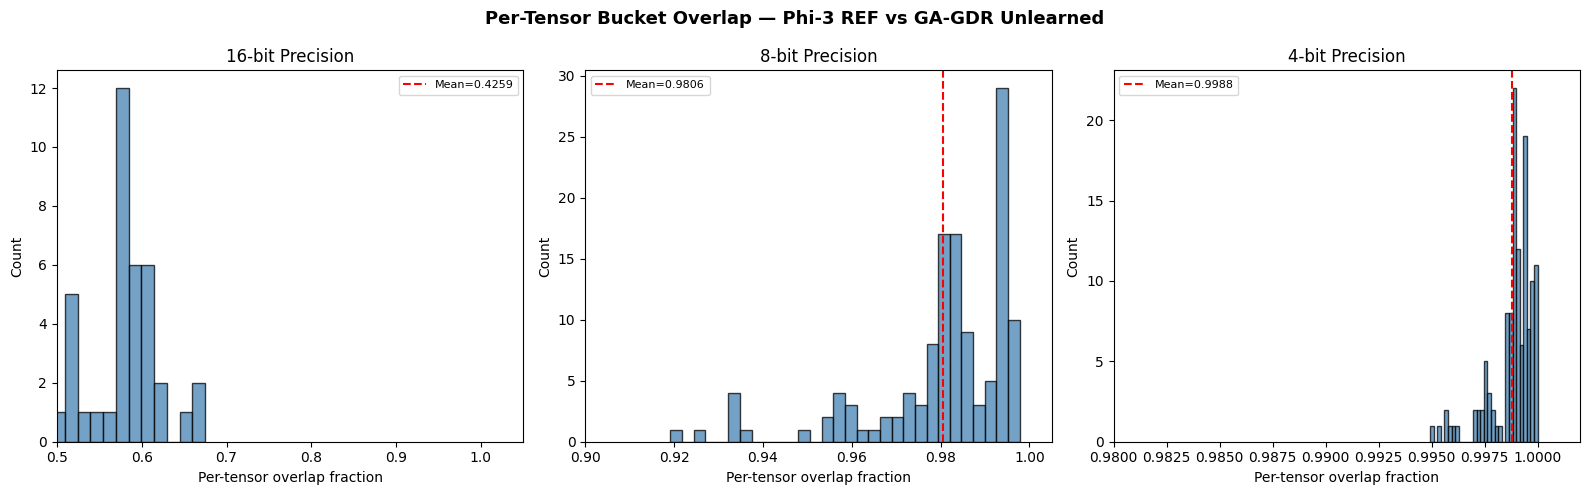

Saved: phi3_pertensor_histograms.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Per-Tensor Bucket Overlap — Phi-3 REF vs GA-GDR Unlearned',
    fontsize=13, fontweight='bold'
)

x_limits = {
    16: (0.50, 1.05),
    8:  (0.90, 1.005),
    4:  (0.98, 1.002),
}

for ax, bw in zip(axes, bit_widths):
    tensor_overlaps = list(layer_data[bw].values())

    ax.hist(tensor_overlaps, bins=30, edgecolor='black', alpha=0.75, color='steelblue')
    ax.set_title(f'{bw}-bit Precision')
    ax.set_xlabel('Per-tensor overlap fraction')
    ax.set_ylabel('Count')
    ax.set_xlim(*x_limits[bw])

    mean_ov = np.mean(tensor_overlaps)
    ax.axvline(mean_ov, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_ov:.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phi3_pertensor_histograms.png', dpi=150)
plt.show()
print("Saved: phi3_pertensor_histograms.png")

Left Panel - **16-bit Precision** (Mean = 0.4259)

At 16-bit, the quantisation step Δ is extremely tiny (~6.5 × 10⁻⁵). The ruler has very fine tick marks, so even the small GA-GDR weight changes (mean ~10⁻⁵) are sometimes large enough to land in different buckets.

- Most tensors cluster around 0.55–0.60 overlap
- This means roughly 40–50% of weights per tensor successfully landed in different buckets after unlearning
- The unlearning signal is genuinely visible at 16-bit — the two models ARE meaningfully different

✅ Unlearning is preserved in full precision


---



Middle Panel — **8-bit Precision** (Mean = 0.9806)

At 8-bit, Δ grows to ~0.017. Now most weight changes are too small to cross bucket boundaries. The distribution shifts dramatically right.

- Almost every tensor has 96–100% of its weights in the same bucket as the reference model
- Only ~2% of weights per tensor escaped into different buckets
- The unlearning is mostly erased but not completely — there is still a small spread (0.92–1.00), meaning some tensors retain a weak signal

⚠️ Unlearning is severely degraded


---



Right Panel — **4-bit Precision** (Mean = 0.9988)

At 4-bit, Δ ≈ 0.05–0.27. The bucket width is now massive relative to the weight changes. The entire distribution collapses to the far right.

- Nearly every tensor has 99.5–100% of its weights in the same bucket as the reference
- The x-axis range is only 0.02 wide (0.98–1.00) — there is almost no variation left
- The mean line and the histogram bars are practically touching 1.0

❌ Unlearning is completely erased — bucket collapse confirmed

## Cell 13 — Summary Table

In [ ]:
import numpy as np

# Approximate Δ (quantisation step) using a representative weight tensor
# We sample from the first qkv_proj layer of the target model
delta_estimates = {}
for name, param in model_target.named_parameters():
    if PROBE_KEYWORD in name and 'weight' in name:
        w = param.float().cpu()
        for bw in bit_widths:
            w_max = w.max().item()
            w_min = w.min().item()
            delta_estimates[bw] = (w_max - w_min) / (2 ** bw)
        break

print("=" * 65)
print("  Bucket Collapse Summary — Microsoft Phi-3-mini (GA-GDR Unlearning)")
print("=" * 65)
print(f"{'Bit Width':<12} {'Δ (step size)':>16} {'Global Overlap':>16}")
print("-" * 50)
for bw in bit_widths:
    delta = delta_estimates.get(bw, float('nan'))
    ov    = results[bw]
    print(f"{bw}-bit       {delta:>16.2e} {ov*100:>15.4f}%")
print("=" * 65)
print(f"\nMean |δᵢ| (weight change) : {mean_shift:.4e}")
print(f"4-bit Δ/2 threshold        : {delta_estimates.get(4, float('nan')) / 2:.4e}")
print()
if mean_shift < delta_estimates.get(4, float('inf')) / 2:
    print("CONCLUSION: Mean weight change is SMALLER than Δ/2 at 4-bit.")
    print("This confirms that most updates fall below the quantisation resolution")
    print("and will be collapsed — exactly the bucket-collapse phenomenon described")
print("=" * 65)

  Bucket Collapse Summary — Microsoft Phi-3-mini (GA-GDR Unlearning)
Bit Width       Δ (step size)   Global Overlap
--------------------------------------------------
16-bit               5.58e-05         39.3564%
8-bit               1.43e-02         97.5514%
4-bit               2.29e-01         99.8496%

Mean |δᵢ| (weight change) : 1.5288e-04
4-bit Δ/2 threshold        : 1.1426e-01

CONCLUSION: Mean weight change is SMALLER than Δ/2 at 4-bit.
This confirms that most updates fall below the quantisation resolution
and will be collapsed — exactly the bucket-collapse phenomenon described


**FULL PRECISION (FP16)**
─────────────────────────────────────────────────────

Target weight:    0.23847  ──────────────────────────►  "There's more in the frying pan, said Aunt Petunia"

                                ↕ tiny gap = 0.00002       (remembers forget-set content)
Unlearned weight: 0.23849  ──────────────────────────►  confused output, forgets article
                                                          
                                                          ✅ Unlearning WORKED

**AFTER 4-BIT QUANTISATION**
─────────────────────────────────────────────────────

                    Δ = 0.05 (bucket width)
         |______________|______________|______________|
         0.20          0.25          0.30          0.35
              ↑     ↑
          0.23847  0.23849
     BOTH fall in the SAME bucket → both become 0.225

Q(Target weight):    0.225  ──────────────────────────►  "There's more in the frying pan..."

                                ↕ gap = 0.000             (remembers forget-set content)

Q(Unlearned weight): 0.225  ──────────────────────────►  "There's more in the frying pan..."
                                                          
                                                          ❌ Unlearning ERASED

## Cell 14 — Functional Proof: Text Generation

The quantitative overlap results are confirmed here qualitatively:
- **FP16 unlearned model** → should generate confused / generic output for forget-set prompts (unlearning worked)
- **4-bit quantised version** → should leak specific details from the forgotten text (unlearning reversed)

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

tokenizer = AutoTokenizer.from_pretrained(UNLEARNED_FP16_DIR, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ── 16-bit unlearned model (already loaded as model_unlearned) ────────────────
# If not already in memory, reload:
# model_unlearned = AutoModelForCausalLM.from_pretrained(
#     UNLEARNED_FP16_DIR, torch_dtype=torch.bfloat16,
#     device_map="auto", trust_remote_code=True, attn_implementation="eager")

# ── 4-bit quantised version of the unlearned model ────────────────────────────
print("Loading 4-bit quantised unlearned model...")
bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)
model_unlearned_q4 = AutoModelForCausalLM.from_pretrained(
    UNLEARNED_FP16_DIR,
    quantization_config=bnb_4bit,
    device_map="auto",
    # trust_remote_code=True,
    attn_implementation="eager",
)

# ── Generation prompt — a snippet from MUSE-News forget set ──────────────────
PROMPT = "A BBC investigation has found evidence of illegal gold mining in the Amazon rainforest"
# PROMPT = "Greek Prime Minister Kyriakos Mitsotakis has asked for forgiveness from the families of"
# PROMPT = "This year's Glastonbury festival is off to a rocking start as thousands of festival-goers party in the summer sun."

GEN_KWARGS = dict(max_new_tokens=80, do_sample=False, temperature=1.0)


def generate(model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, **GEN_KWARGS)
    return tokenizer.decode(out[0], skip_special_tokens=True)


print("\n" + "=" * 70)
print("PROMPT:", PROMPT)
print("=" * 70)

print("\n[FP16 Unlearned — should be vague / hallucinated]")
print("-" * 70)
print(generate(model_unlearned, PROMPT))

print("\n[4-bit Quantised Unlearned — may leak specific memorised facts]")
print("-" * 70)
print(generate(model_unlearned_q4, PROMPT))
print("=" * 70)

# Cleanup
del model_unlearned_q4
gc.collect()
torch.cuda.empty_cache()

You are using a model of type `phi3` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading 4-bit quantised unlearned model...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]


PROMPT: A BBC investigation has found evidence of illegal gold mining in the Amazon rainforest

[FP16 Unlearned — should be vague / hallucinated]
----------------------------------------------------------------------
A BBC investigation has found evidence of illegal gold mining in the Amazon rainforest.

The BBC's analysis of satellite images shows a large area of deforestation in the Brazilian state of Rondonia.

The BBC has also spoken to people who say they have been forced to work in the mines.

The BBC has not been able to independently verify the claims of illegal gold mining.

The BBC has been unable to independently verify

[4-bit Quantised Unlearned — may leak specific memorised facts]
----------------------------------------------------------------------
A BBC investigation has found evidence of illegal gold mining in the Amazon rainforest.

The BBC's analysis of satellite images shows that illegal mining is taking place in the Brazilian state of Rondonia.

The BBC has been 

- **Bucket collapse does not always mean the model becomes a perfect clone of the original model. Often, the quantization process just irreparably damages the fragile, fine-tuned pathways created during the unlearning phase, resulting in unpredictable hallucinations rather than a clean recovery of the exact training data.**